# TD learning gamma sweep: leave-probability heatmaps

Loads the 15 completed runs from `bash_scripts/train_gamma_sweep.sh` (5 gammas x 3 networks) and, for
each patch type, plots a 5x3 grid of P(leave) heatmaps. Rows are gamma (increasing top -> bottom),
columns are the 3 networks trained at that gamma. Two grids per patch type: failures measured as
**consecutive** failures, and as **cumulative** failures (both vs. cumulative rewards), matching
`plot_stop_fraction` in the behavioral notebooks.

In [1]:
%load_ext autoreload
%autoreload 

import os, sys, glob
sys.path.insert(0, os.path.abspath('..'))     # code/  (behavioral_plotting, ...)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import jax
jax.config.update('jax_platforms', 'cpu')
plt.rcParams['font.family'] = 'Helvetica Light'

from behavioral_plotting import load_odor_site_df, odor_colors
from aux_funcs import format_plot

REPO = os.path.abspath('../..')               # repo root
GAMMAS   = [0.5, 0.8, 0.95, 0.99, 0.999]       # top -> bottom
SUFFIXES = ['0p5', '0p8', '0p95', '0p99', '0p999']
NETS     = [0, 1, 2]

## Locate the 15 trajectory files

Each run saved a training snapshot under `results/<exp>/step_*/traj_*.pkl`.

In [2]:
def traj_path(suffix, net):
    exp = f'fixed_exp_gru_initial_prob_offset_gamma_{suffix}_net{net}'
    hits = sorted(glob.glob(f'{REPO}/results/{exp}/step_*/traj_*.pkl'))
    if not hits:
        raise FileNotFoundError(f'no trajectory pkl for {exp}')
    return hits[-1]   # latest snapshot

paths = [[traj_path(suf, net) for net in NETS] for suf in SUFFIXES]
for suf, row in zip(SUFFIXES, paths):
    print(f'gamma {suf}: ' + ', '.join(os.path.relpath(p, REPO) for p in row))
print('total files:', sum(len(r) for r in paths))

gamma 0p5: results/fixed_exp_gru_initial_prob_offset_gamma_0p5_net0/step_00/traj_000499.pkl, results/fixed_exp_gru_initial_prob_offset_gamma_0p5_net1/step_00/traj_000499.pkl, results/fixed_exp_gru_initial_prob_offset_gamma_0p5_net2/step_00/traj_000499.pkl
gamma 0p8: results/fixed_exp_gru_initial_prob_offset_gamma_0p8_net0/step_00/traj_000499.pkl, results/fixed_exp_gru_initial_prob_offset_gamma_0p8_net1/step_00/traj_000499.pkl, results/fixed_exp_gru_initial_prob_offset_gamma_0p8_net2/step_00/traj_000499.pkl
gamma 0p95: results/fixed_exp_gru_initial_prob_offset_gamma_0p95_net0/step_00/traj_000499.pkl, results/fixed_exp_gru_initial_prob_offset_gamma_0p95_net1/step_00/traj_000499.pkl, results/fixed_exp_gru_initial_prob_offset_gamma_0p95_net2/step_00/traj_000499.pkl
gamma 0p99: results/fixed_exp_gru_initial_prob_offset_gamma_0p99_net0/step_00/traj_000499.pkl, results/fixed_exp_gru_initial_prob_offset_gamma_0p99_net1/step_00/traj_000499.pkl, results/fixed_exp_gru_initial_prob_offset_gamma_0p

## Load all 15 odor-site dataframes (heavy: parses each run)

In [3]:
# dfs_grid[r][c] = dataframe for GAMMAS[r], network c
dfs_grid = [
    [load_odor_site_df(paths[r][c], nn_num=c, brief=False) for c in range(len(NETS))]
    for r in range(len(GAMMAS))
]
print('loaded', sum(len(row) for row in dfs_grid), 'dataframes')

Session data loaded
Session summaries generated


Session data loaded
Session summaries generated


Session data loaded
Session summaries generated


Session data loaded
Session summaries generated


Session data loaded
Session summaries generated


...

Session data loaded
Session summaries generated


Session data loaded
Session summaries generated


Session data loaded
Session summaries generated


Session data loaded
Session summaries generated


Session data loaded
Session summaries generated
loaded 15 dataframes


## Heatmap helpers

`leave_matrix` reproduces `plot_stop_fraction`'s P(leave) = 1 - mean(stopped) pivot for one df and
patch type; `x_col='consecutive_misses'` or `'cumulative_misses'` (the latter computed per patch as
`cumcount() - rewards_seen_in_patch`). `plot_leave_grid` tiles these into the 5x3 grid.

In [4]:
def leave_matrix(df, x_col, patch_type, y_col='rewards_seen_in_patch', min_n=5):
    d = df[df['patch_type'] == patch_type].copy()
    if x_col == 'cumulative_misses':
        d['cumulative_misses'] = (
            d.groupby(['session_number', 'patch_number']).cumcount() - d[y_col]
        ).clip(lower=0)
    filt = d.groupby([y_col, x_col]).filter(lambda g: len(g) >= min_n)
    grouped = filt.groupby([y_col, x_col])['stopped'].mean().reset_index()
    mat = grouped.pivot(index=y_col, columns=x_col, values='stopped')
    return 1.0 - mat   # P(leave)


def plot_leave_grid(dfs_grid, gammas, patch_type, x_col, x_label, min_n=5,
                    gamma_min=0.95, cmap='YlGnBu', vmin=0, vmax=1,
                    label_fontsize=12, tick_fontsize=10):
    def _thin_ticks(ax, x_vals, y_vals, max_ticks=6, show_labels=True):
        for vals, set_t, set_l in [(x_vals, ax.set_xticks, ax.set_xticklabels),
                                   (y_vals, ax.set_yticks, ax.set_yticklabels)]:
            n = len(vals)
            if n == 0:
                continue
            step = max(1, int(np.ceil(n / max_ticks)))
            idx = np.arange(0, n, step)
            set_t(idx + 0.5)
            set_l([f'{vals[i]:g}' for i in idx] if show_labels else [],
                  fontsize=tick_fontsize, rotation=0)

    # (4) only gammas >= gamma_min
    rows = [i for i, g in enumerate(gammas) if g >= gamma_min]
    gammas_sel = [gammas[i] for i in rows]
    grid = [dfs_grid[i] for i in rows]
    nrows, ncols = len(gammas_sel), len(grid[0])

    # matrices reindexed to a common (y, x) grid -> shared x/y limits
    mats = [[leave_matrix(grid[r][c], x_col, patch_type, min_n=min_n)
             for c in range(ncols)] for r in range(nrows)]
    all_idx = sorted(set().union(*(set(m.index) for row in mats for m in row)))
    all_col = sorted(set().union(*(set(m.columns) for row in mats for m in row)))
    mats = [[m.reindex(index=all_idx, columns=all_col) for m in row] for row in mats]

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 2.7, nrows * 2.4))
    axes = np.atleast_2d(axes)
    for r, gamma in enumerate(gammas_sel):
        for c in range(ncols):
            ax = axes[r, c]
            sns.heatmap(mats[r][c], ax=ax, cmap=cmap, vmin=vmin, vmax=vmax, cbar=False)
            ax.invert_yaxis()
            # tick labels only on the bottom-left corner subplot
            _thin_ticks(ax, all_col, all_idx, show_labels=True)
            ax.set_title(f'net {c}' if r == 0 else '', fontsize=10)
            ax.set_xlabel(x_label if r == nrows - 1 else '', fontsize=label_fontsize)
            ax.set_ylabel(f'$\\gamma$ = {gamma}\nCumulative rewards' if c == 0 else '', fontsize=label_fontsize)

    format_plot(axes, ticklabelsize=tick_fontsize, axislabelsize=label_fontsize, ticklength=4, bottomspine=False, leftspine=False)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin, vmax)); sm.set_array([])
    cb = fig.colorbar(sm, ax=axes.ravel().tolist(), fraction=0.02, pad=0.02, label='P(leave)')
    cb.outline.set_visible(False)
    fig.suptitle(f'patch type {patch_type}:  {x_label} vs cumulative rewards', fontsize=14, y=1.005)
    plt.show()
    return fig

## Patch type 1

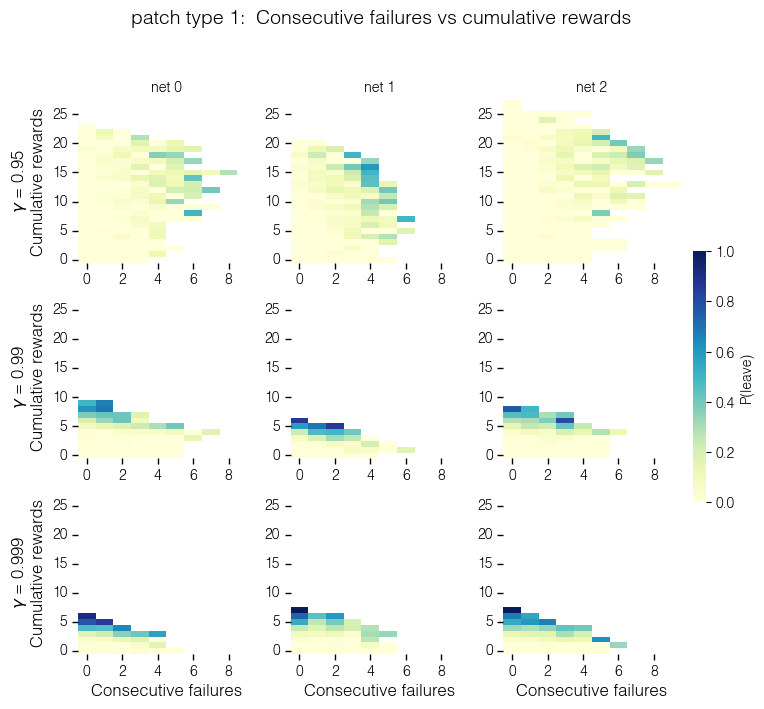

In [5]:
plot_leave_grid(dfs_grid, GAMMAS, patch_type=1,
                x_col='consecutive_misses', x_label='Consecutive failures');

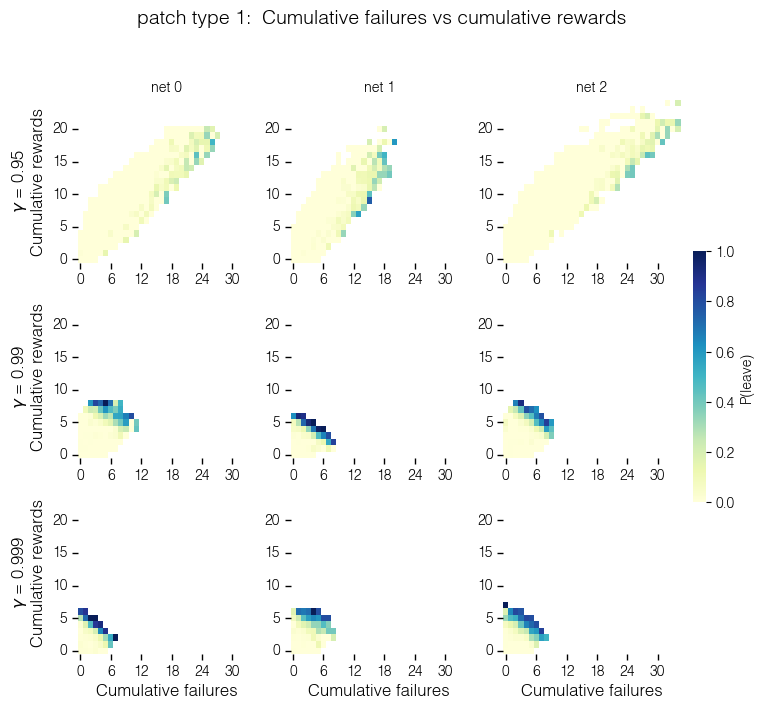

In [6]:
plot_leave_grid(dfs_grid, GAMMAS, patch_type=1,
                x_col='cumulative_misses', x_label='Cumulative failures');

## Patch type 2

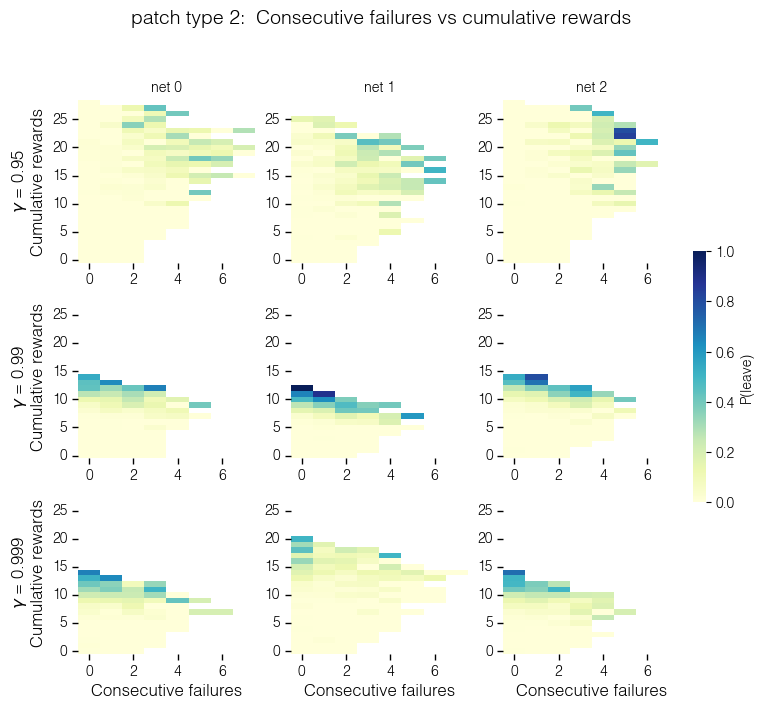

In [7]:
plot_leave_grid(dfs_grid, GAMMAS, patch_type=2,
                x_col='consecutive_misses', x_label='Consecutive failures');

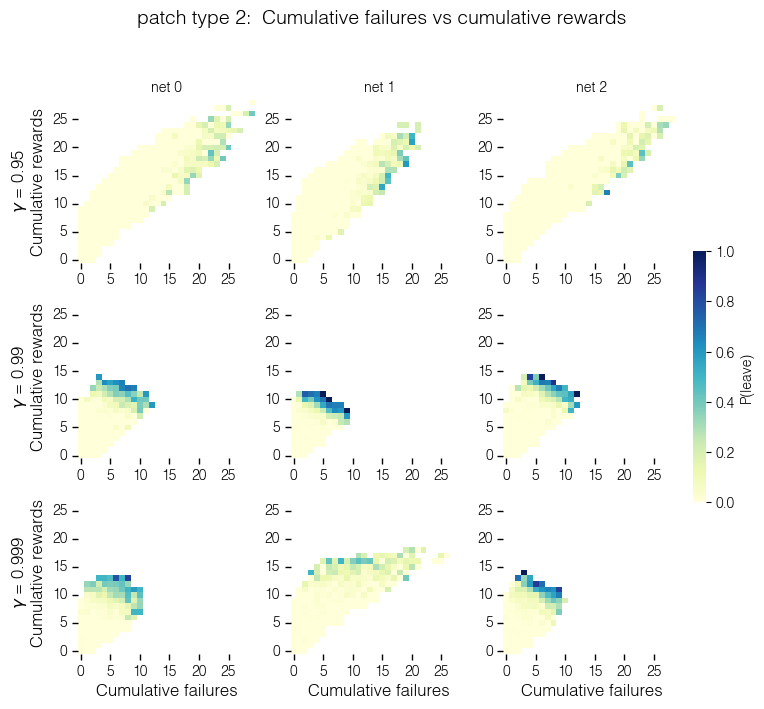

In [8]:
plot_leave_grid(dfs_grid, GAMMAS, patch_type=2,
                x_col='cumulative_misses', x_label='Cumulative failures');

## Patch trajectories (color-coded by stop / reward outcome)

Same 3x3 grid (gamma x network). Each subplot is a **patch number x site index** matrix for the
first `n_patches` patches of the given type: **green** = rewarded stop, **grey** = unrewarded stop,
**red** = opt out (the agent did not stop). White = the patch had no site at that index.

In [9]:
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches

def patch_cat_matrix(df, patch_type, n_patches):
    """(n_patches, n_sites) matrix of per-site outcome categories for the first n patches of a type.
    -1 = no site, 0 = opt out, 1 = unrewarded stop, 2 = rewarded stop."""
    d = df[df['patch_type'] == patch_type].copy()
    d['site_index'] = d.groupby(['session_number', 'patch_number']).cumcount()
    # a stop is rewarded iff cumulative rewards_seen_in_patch increases at the next site in the
    # patch. (The per-site 'rewarded' column is unreliable -- it desyncs from rewards_seen_in_patch.)
    rs_next = d.groupby(['session_number', 'patch_number'])['rewards_seen_in_patch'].shift(-1)
    d['site_rewarded'] = (rs_next - d['rewards_seen_in_patch']) > 0
    d['patch_id'] = d.groupby(['session_number', 'patch_number']).ngroup()
    ids = list(dict.fromkeys(d['patch_id']))[:n_patches]        # first n patches (temporal order)
    sel = d[d['patch_id'].isin(ids)].copy()
    sel['row'] = sel['patch_id'].map({p: i for i, p in enumerate(ids)})
    stopped = sel['stopped'].values == 1
    cat = np.where(stopped, np.where(sel['site_rewarded'].values, 2, 1), 0)
    n_sites = int(sel['site_index'].max()) + 1 if len(sel) else 1
    M = np.full((n_patches, n_sites), -1, dtype=int)
    M[sel['row'].values, sel['site_index'].values.astype(int)] = cat
    return M


def plot_patch_traj_grid(dfs_grid, gammas, patch_type, n_patches=40, gamma_min=0.95, gamma_max=1.0,
                         col_width=4, gap=1, label_fontsize=12, tick_fontsize=10):
    rows = [i for i, g in enumerate(gammas) if (g >= gamma_min and g <= gamma_max)]
    gammas_sel = [gammas[i] for i in rows]
    grid = [dfs_grid[i] for i in rows]
    nrows, ncols = len(gammas_sel), len(grid[0])

    mats = [[patch_cat_matrix(grid[r][c], patch_type, n_patches) for c in range(ncols)]
            for r in range(nrows)]
    n_sites = max(m.shape[1] for row in mats for m in row)     # common site axis (now the y axis)

    cat_colors = {2: odor_colors[patch_type], 1: '#dddddd', 0: '#ac37fa'}   # light grey / bright red

    def to_img(M):
        # pad sites, transpose so columns = patches, colorize, then widen columns + white gaps
        P = np.full((n_patches, n_sites), -1, dtype=int)
        P[:, :M.shape[1]] = M
        base = np.ones((n_sites, n_patches, 3))                # white; rows = site, cols = patch
        Pt = P.T
        for cat, col in cat_colors.items():
            base[Pt == cat] = mcolors.to_rgb(col)
        W = n_patches * col_width + (n_patches - 1) * gap
        img = np.ones((n_sites, W, 3))
        for p in range(n_patches):
            x = p * (col_width + gap)
            img[:, x:x + col_width, :] = base[:, p][:, None, :]
        return img

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 2.7, nrows * 2.4))
    axes = np.atleast_2d(axes)
    for r, gamma in enumerate(gammas_sel):
        for c in range(ncols):
            ax = axes[r, c]
            ax.imshow(to_img(mats[r][c]), aspect='auto', interpolation='nearest')
            ax.set_title(f'net {c}' if r == 0 else '', fontsize=10)
            ax.set_xlabel('patch #' if r == nrows - 1 else '', fontsize=label_fontsize)
            ax.set_ylabel(f'$\\gamma$ = {gamma}\nsite index' if c == 0 else '', fontsize=label_fontsize)
            ax.invert_yaxis()

    format_plot(axes, ticklabelsize=tick_fontsize, axislabelsize=label_fontsize)
    # tick labels only on the bottom-left corner subplot
    for r in range(nrows):
        for c in range(ncols):
            ax = axes[r, c]
            if r == nrows - 1 and c == 0:
                pidx = np.arange(0, n_patches, max(1, int(np.ceil(n_patches / 6))))
                ax.set_xticks(pidx * (col_width + gap) + (col_width - 1) / 2)
                ax.set_xticklabels([str(p) for p in pidx], fontsize=tick_fontsize)
                sidx = np.arange(0, n_sites, max(1, int(np.ceil(n_sites / 6))))
                ax.set_yticks(sidx)
                ax.set_yticklabels([str(x) for x in sidx], fontsize=tick_fontsize)
            else:
                ax.tick_params(labelbottom=False, labelleft=False)

    handles = [mpatches.Patch(color=cat_colors[2], label='rewarded stop'),
               mpatches.Patch(color=cat_colors[1], label='unrewarded stop'),
               mpatches.Patch(color=cat_colors[0], label='opt out')]
    fig.legend(handles=handles, loc='lower center', ncol=3, frameon=False,
               fontsize=11, bbox_to_anchor=(0.5, -0.02))
    fig.suptitle(f'patch type {patch_type}:  patch trajectories', fontsize=14, y=1.005)
    plt.show()
    return fig

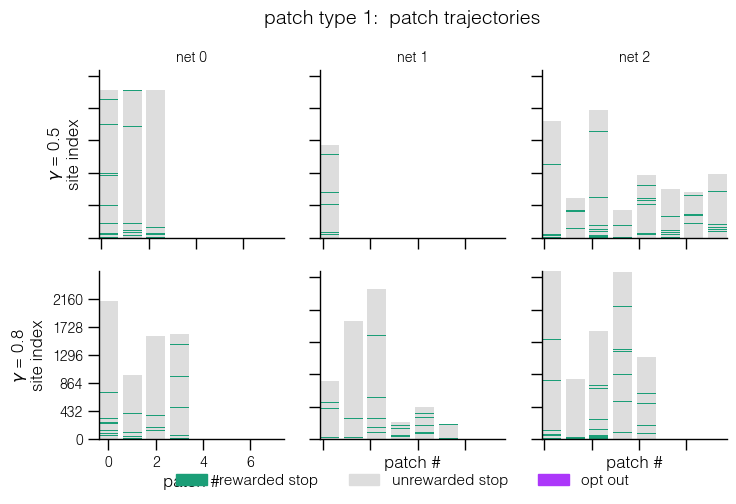

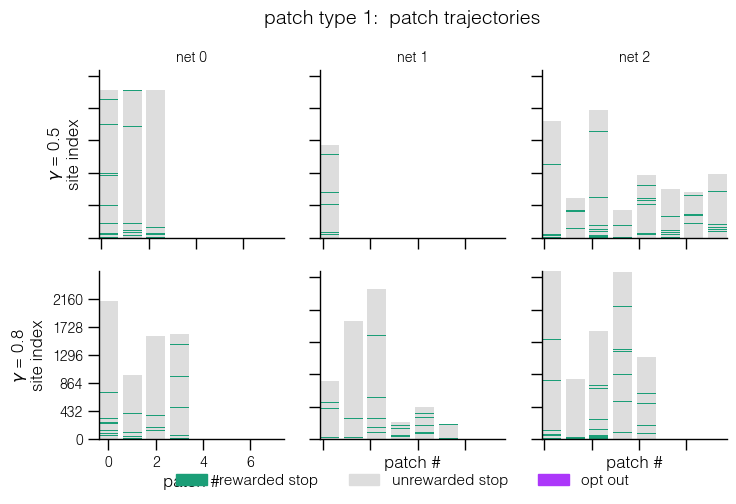

In [10]:
plot_patch_traj_grid(dfs_grid, GAMMAS, patch_type=1, n_patches=8, gamma_min=0, gamma_max=0.9)

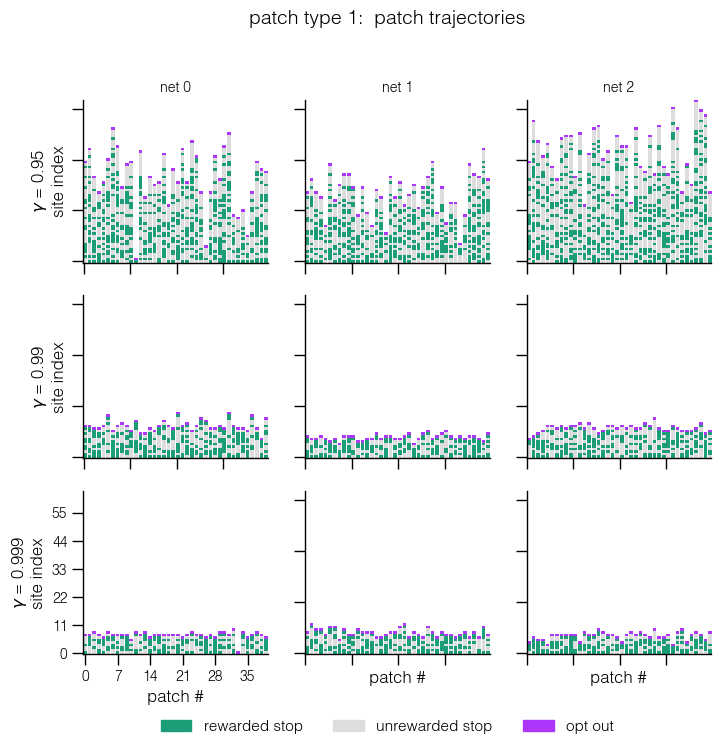

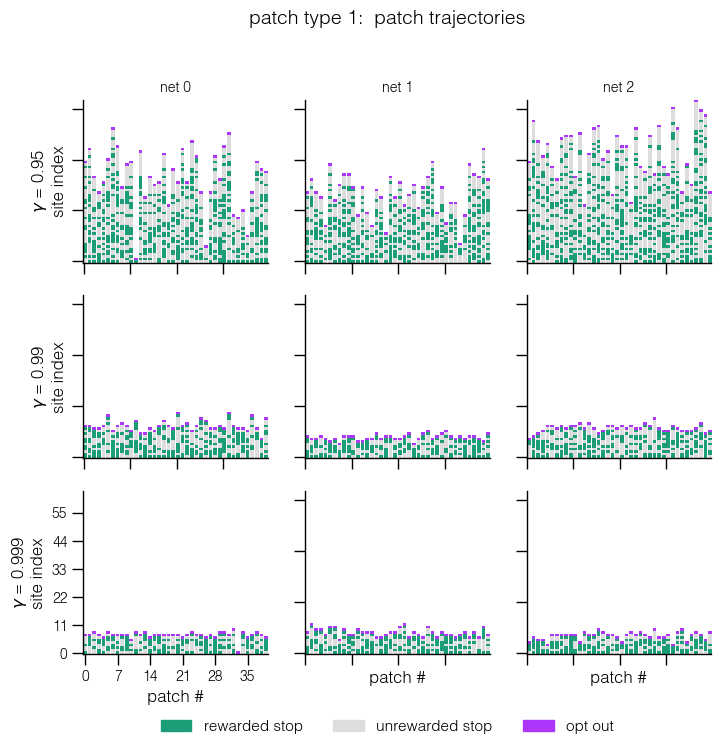

In [11]:
plot_patch_traj_grid(dfs_grid, GAMMAS, patch_type=1, n_patches=40)

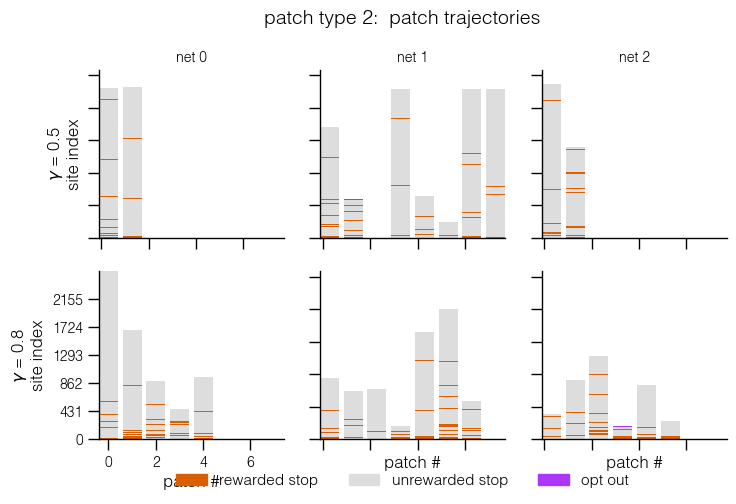

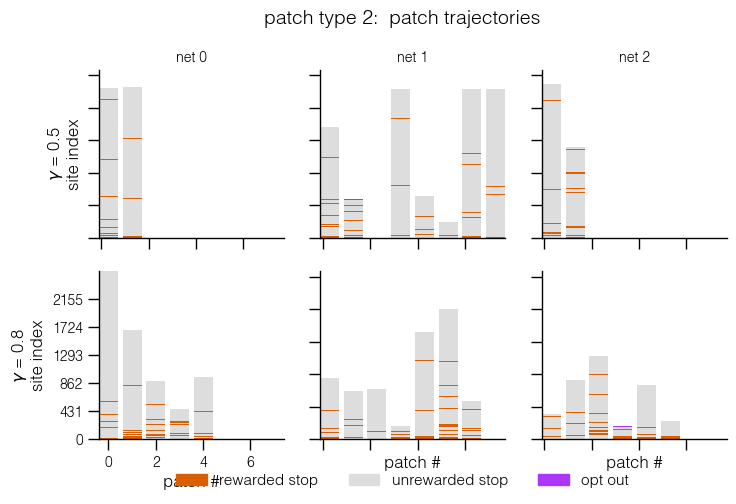

In [12]:
plot_patch_traj_grid(dfs_grid, GAMMAS, patch_type=2, n_patches=8, gamma_min=0, gamma_max=0.9)

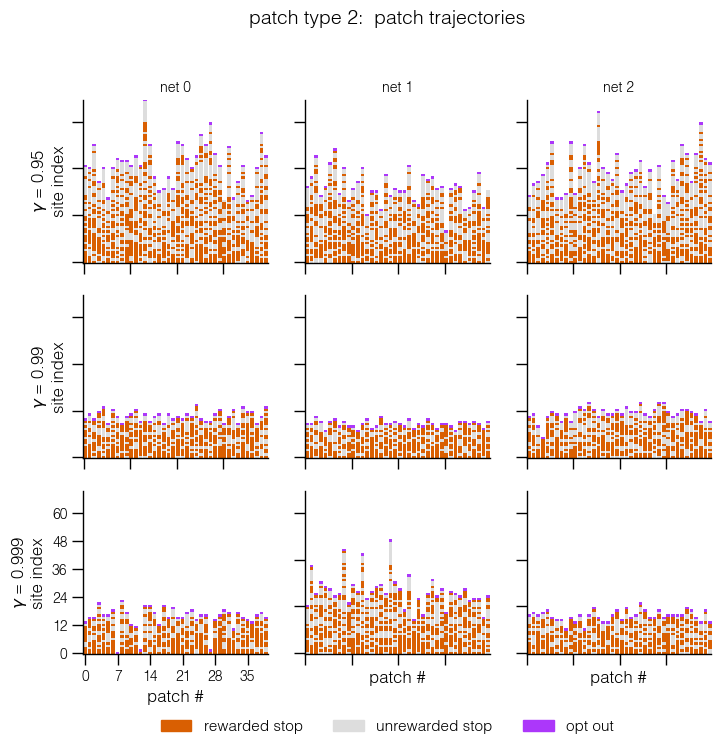

In [13]:
plot_patch_traj_grid(dfs_grid, GAMMAS, patch_type=2, n_patches=40);

## Combination: trajectories + P(leave) heatmaps per gamma (one network)

3x3 grid for a single network: rows = gamma (0.95 / 0.99 / 0.999); columns = patch trajectories,
P(leave) vs consecutive fails, P(leave) vs cumulative fails.

In [61]:
def plot_combination(dfs_grid, gammas, patch_type, network=0, gamma_min=0.95, n_patches=40,
                     col_width=4, gap=1, min_n=5, cmap='YlGnBu',
                     label_fontsize=12, tick_fontsize=10):
    """3x3 grid for a single network: rows = gamma (>= gamma_min), columns =
    [patch trajectories | P(leave) vs consecutive fails | P(leave) vs cumulative fails]."""
    def _thin(vals, max_ticks=5):
        n = len(vals)
        if n == 0:
            return np.array([], int)
        return np.arange(0, n, max(1, int(np.ceil(n / max_ticks))))

    rows = [i for i, g in enumerate(gammas) if g >= gamma_min]
    gammas_sel = [gammas[i] for i in rows]
    dfs = [dfs_grid[i][network] for i in rows]
    nrows = len(rows)
    cat_colors = {2: odor_colors[patch_type], 1: '#dddddd', 0: '#ac37fa'}

    # column 0: patch-trajectory images (shared site axis, columns = patches, white gaps between)
    cmats = [patch_cat_matrix(df, patch_type, n_patches) for df in dfs]
    n_sites = max(m.shape[1] for m in cmats)

    def traj_img(M):
        P = np.full((n_patches, n_sites), -1, int); P[:, :M.shape[1]] = M
        base = np.ones((n_sites, n_patches, 3)); Pt = P.T
        for cat, col in cat_colors.items():
            base[Pt == cat] = mcolors.to_rgb(col)
        W = n_patches * col_width + (n_patches - 1) * gap
        img = np.ones((n_sites, W, 3))
        for p in range(n_patches):
            x = p * (col_width + gap)
            img[:, x:x + col_width, :] = base[:, p][:, None, :]
        return img

    # columns 1,2: P(leave) heatmaps -> shared cum-reward y across all, own x per column
    con = [leave_matrix(df, 'consecutive_misses', patch_type, min_n=min_n) for df in dfs]
    cum = [leave_matrix(df, 'cumulative_misses', patch_type, min_n=min_n) for df in dfs]
    yv = sorted(set().union(*(set(m.index) for m in con + cum)))
    cx = sorted(set().union(*(set(m.columns) for m in con)))
    ux = sorted(set().union(*(set(m.columns) for m in cum)))
    con = [m.reindex(index=yv, columns=cx) for m in con]
    cum = [m.reindex(index=yv, columns=ux) for m in cum]

    fig, axes = plt.subplots(nrows, 3, figsize=(3 * 3.2, nrows * 2.5),
                             gridspec_kw={'wspace': 0.55})
    axes = np.atleast_2d(axes)
    titles = ['patch trajectories', 'consecutive fails', 'cumulative fails']
    xlabels = ['patch #', 'consecutive fails', 'cumulative fails']
    for r in range(nrows):
        gamma = gammas_sel[r]
        ax0, ax1, ax2 = axes[r]
        ax0.imshow(traj_img(cmats[r]), aspect='auto', interpolation='nearest'); ax0.invert_yaxis()
        sns.heatmap(con[r], ax=ax1, cmap=cmap, vmin=0, vmax=1, cbar=False); ax1.invert_yaxis()
        sns.heatmap(cum[r], ax=ax2, cmap=cmap, vmin=0, vmax=1, cbar=False); ax2.invert_yaxis()
        for cc, ax in enumerate((ax0, ax1, ax2)):
            if r == 0:
                ax.set_title(titles[cc], fontsize=10)
            ax.set_xlabel(xlabels[cc] if r == nrows - 1 else '', fontsize=label_fontsize)
        ax0.set_ylabel(f'$\\gamma$ = {gamma}\nsite index', fontsize=label_fontsize)
        ax1.set_ylabel('cum. rewards', fontsize=label_fontsize)
        ax2.set_ylabel('cum. rewards', fontsize=label_fontsize)

    format_plot(axes, ticklabelsize=tick_fontsize, axislabelsize=label_fontsize)

    for r in range(nrows):
        ax0, ax1, ax2 = axes[r]
        # col 0 trajectory: x = patch # (all rows), y = site index
        pidx = _thin(range(n_patches))
        ax0.set_xticks(pidx * (col_width + gap) + (col_width - 1) / 2)
        ax0.set_xticklabels([str(p) for p in pidx], fontsize=tick_fontsize)
        sidx = _thin(range(n_sites))
        ax0.set_yticks(sidx); ax0.set_yticklabels([str(s) for s in sidx], fontsize=tick_fontsize)
        # heatmaps: x = fails (own per column, all rows), y = cum rewards (shared, labeled on both)
        for ax, cols in ((ax1, cx), (ax2, ux)):
            xi = _thin(cols)
            ax.set_xticks(xi + 0.5)
            ax.set_xticklabels([f'{cols[i]:g}' for i in xi], fontsize=tick_fontsize, rotation=0)
        yi = _thin(yv)
        for ax in (ax1, ax2):
            ax.set_yticks(yi + 0.5)
            ax.set_yticklabels([f'{yv[i]:g}' for i in yi], fontsize=tick_fontsize)

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, 1)); sm.set_array([])
    cb = fig.colorbar(sm, ax=axes[:, 1:].ravel().tolist(), fraction=0.02, pad=0.02, label='P(leave)')
    cb.outline.set_visible(False)
    handles = [mpatches.Patch(color=cat_colors[2], label='rewarded stop'),
               mpatches.Patch(color=cat_colors[1], label='unrewarded stop'),
               mpatches.Patch(color=cat_colors[0], label='opt out')]
    fig.legend(handles=handles, loc='lower center', ncol=3, frameon=False,
               fontsize=11, bbox_to_anchor=(0.5, -0.03))
    fig.suptitle(f'patch type {patch_type}  (net {network})', fontsize=14, y=1.01)
    plt.show()
    return fig

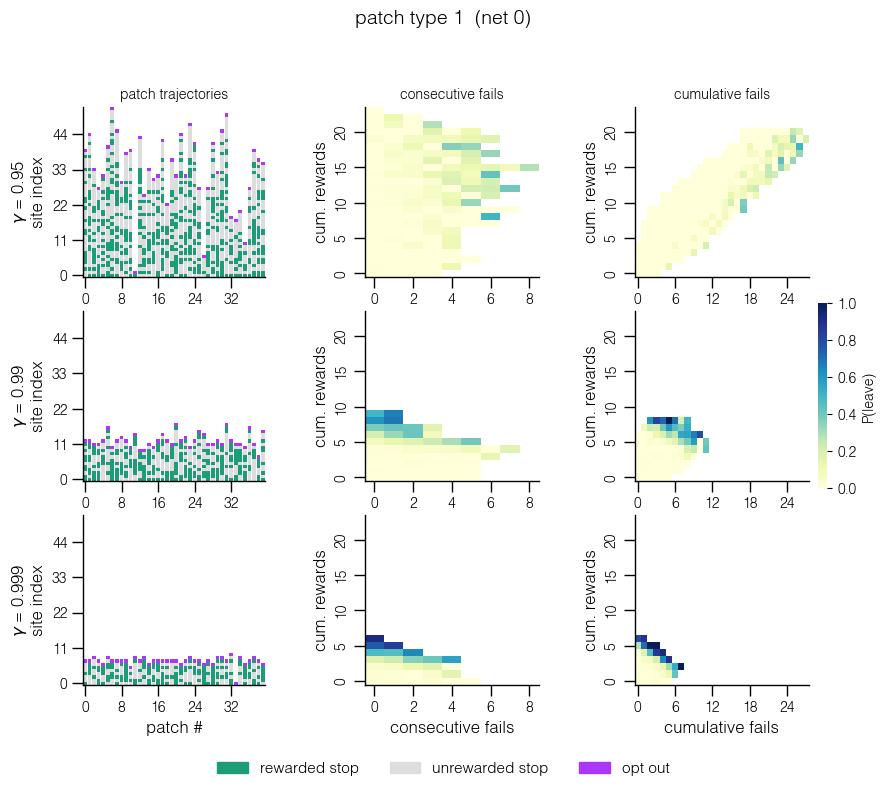

In [62]:
plot_combination(dfs_grid, GAMMAS, patch_type=1, network=0);

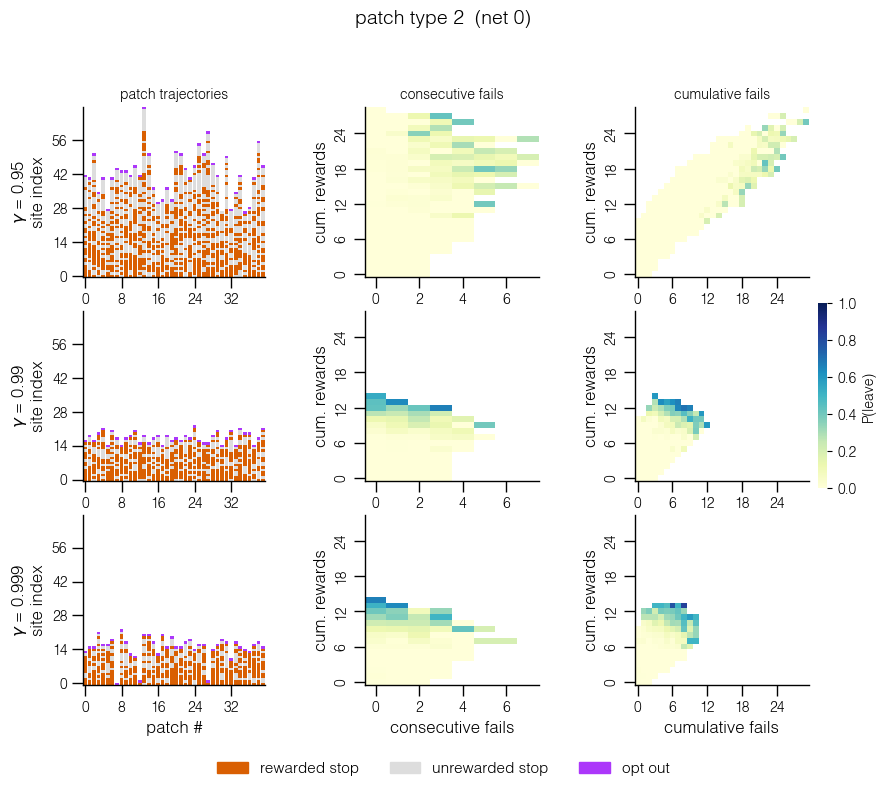

In [63]:
plot_combination(dfs_grid, GAMMAS, patch_type=2, network=0);